# BKM Checks

Test notebook to check if all the BKM functions work as expected and return the same results

In [1]:
import tensorflow as tf
import jax 
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from bkm10_tf32 import BKM10 as BKM10_TF32
from bkm10_jax import BKM10 as BKM10_JAX

import os
print(os.environ.get('PATH'))

2026-09-02 00:17:04.002574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788322624.027912  111253 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788322624.032318  111253 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788322624.046246  111253 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788322624.046263  111253 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788322624.046264  111253 computation_placer.cc:177] computation placer alr

/home/pratik/.venvs/code/bin:/home/pratik/.vscode-server/bin/08d4889f9ec4a1685d257b9b95de036c8e1ce1e5/bin/remote-cli:/usr/local/cuda-13.1/bin:/home/pratik/.venvs/code/bin:/home/pratik/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/usr/lib/wsl/lib:/mnt/c/WINDOWS/system32:/mnt/c/WINDOWS:/mnt/c/WINDOWS/System32/Wbem:/mnt/c/WINDOWS/System32/WindowsPowerShell/v1.0/:/mnt/c/WINDOWS/System32/OpenSSH/:/mnt/c/Program Files (x86)/NVIDIA Corporation/PhysX/Common:/mnt/c/Program Files/NVIDIA Corporation/NVIDIA app/NvDLISR:/mnt/c/Program Files/Wolfram Research/WolframScript/:/mnt/c/Program Files/dotnet/:/mnt/c/Users/Pratik T/AppData/Local/Microsoft/WindowsApps:/mnt/c/Users/Pratik T/AppData/Local/Programs/Microsoft VS Code/bin:/mnt/c/Users/Pratik T/AppData/Local/PowerToys/:/snap/bin


In [2]:
cffs = [-2.51484, 1.34742, 2.18225, 126.28265, 3.20275, 1.49975, 0, 0]

phi = np.linspace(-np.pi, np.pi, 100)

k = 5.55
Q2 = 1.74
xB = 0.359
t = -0.183

kins = [k, Q2, xB, t]

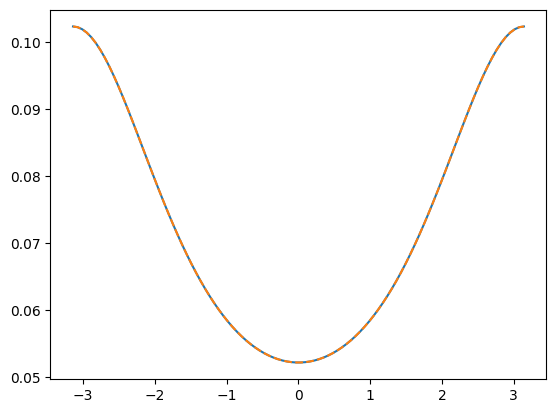

In [4]:
plus_tf32 = BKM10_TF32(*tf.convert_to_tensor(kins, tf.float32), helc=1)
mins_tf32 = BKM10_TF32(*tf.convert_to_tensor(kins, tf.float32), helc=-1)
phi_tf32 = tf.convert_to_tensor(phi, dtype=tf.float32)

splus = plus_tf32.calculate_cross_section(phi_tf32, tf.expand_dims(tf.convert_to_tensor(cffs, dtype=tf.float32), axis=0))
smins = mins_tf32.calculate_cross_section(phi_tf32, tf.expand_dims(tf.convert_to_tensor(cffs, dtype=tf.float32), axis=0))

dsig_tf32 = 0.5*(splus+smins)
delsig_tf32 = 0.5*(splus-smins)


plus_jax = BKM10_JAX(*jnp.asarray(kins), helc=1)
mins_jax = BKM10_JAX(*jnp.asarray(kins), helc=-1)
phi_jax = jnp.asarray(phi)

splus = plus_jax.calculate_cross_section(phi_jax, jnp.expand_dims(jnp.asarray(cffs), axis=0))
smins = mins_jax.calculate_cross_section(phi_jax, jnp.expand_dims(jnp.asarray(cffs), axis=0))

dsig_jax = 0.5*(splus+smins)
delsig_jax = 0.5*(splus-smins)

plt.plot(phi_tf32, dsig_tf32, phi_jax, dsig_jax, '--')